In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_blobs


Always standardizes your data in KNN.  
KNN act as baseline like for other models.

In [3]:
plt.style.use('ggplot')

In [4]:
X, y = make_blobs(n_samples=2000, n_features=2, centers=3, cluster_std=3, random_state=42)
n_features = X.shape[1]
m = X.shape[0]
print(X.shape, y.shape)

(2000, 2) (2000,)


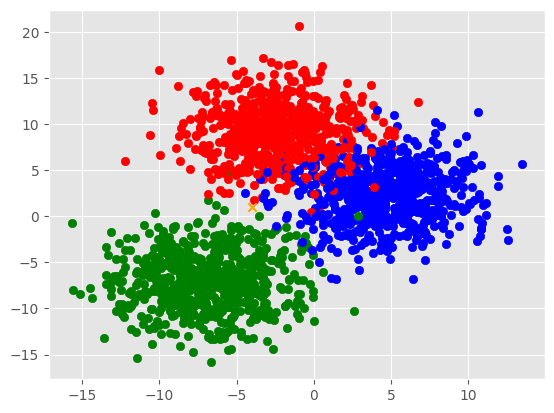

In [15]:
xt = np.array([-4, 1])

for i in range(m):
    if y[i] == 0:
        plt.scatter(X[i, 0], X[i, 1], color='red')
    elif y[i] == 1:
        plt.scatter(X[i, 0], X[i, 1], color='blue')
    else:
        plt.scatter(X[i, 0], X[i, 1], color='green')
        
plt.scatter(xt[0], xt[1], color='orange', marker='x')

In [ ]:
def distance(p,q):
    return np.sqrt(np.sum((p-q)**2))

def knn(X,y, xt):
    m = X.shape[0]
    dlist = []
    
    for i in range(m):
        d = distance(X[i], xt)
        dlist.append((d, y[i]))
    dlist = sorted(dlist)
    dlist = np.array(dlist[:5])
    #print(dlist)
    labels = dlist[:, 1]
    labels, cnts = np.unique(labels, return_counts=True)
    idx = cnts.argmax()
    prod = labels[idx]
    return int(prod)

In [21]:
knn(X, y, xt)

1

In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.945
